# DNNLS Live Arena — Two Moons starter notebook

This notebook shows the two ways to produce a submission for the **Two Moons — Decision Boundary Challenge**:

* **Option A – prediction CSV** (safest, no code is executed on the server), and
* **Option B – Python bundle** (`submission.zip` with `submission.py` + `weights.pt`, run in a sandbox).

Workflow: train here in Colab → download the artifact → upload it on the Arena student page in your browser.

> This notebook is an *export helper*, not a model-tuning exercise. Replace the simple models with your own ideas.


## 0. Get the public challenge files

The three public files (`train.csv`, `test_features.csv`, `visualization_grid.csv`) are committed in the
project repository, so Colab can download them straight from GitHub. The Arena server also serves them,
but a server on your lecturer's laptop (classroom Wi-Fi, `localhost`, ...) is *not* reachable from Colab,
which runs in Google's cloud.

Order of attempts: GitHub → Arena URL → manual upload with the file picker.


In [ ]:
DATA_BASE_URL = "https://raw.githubusercontent.com/aljiro/interactive_coding/main/examples/data"   # public challenge files in the repository
ARENA_URL = "http://localhost:8000"  # address shown on the projector (only reachable from Colab if deployed on a public VM)
CHALLENGE = "moons"
FILES = ["train.csv", "test_features.csv", "visualization_grid.csv"]

import os, requests

def fetch(base_url):
    for name in FILES:
        r = requests.get(f"{base_url}/{name}", timeout=10)
        r.raise_for_status()
        if not r.text.startswith("id,"):
            raise ValueError(f"{name}: unexpected content")
        open(name, "wb").write(r.content)
        print("downloaded", name, len(r.content), "bytes")

try:
    fetch(DATA_BASE_URL)
except Exception as exc:
    print("GitHub download failed:", exc)
    try:
        fetch(f"{ARENA_URL}/api/challenges/{CHALLENGE}/resources")
    except Exception as exc2:
        print("Arena download failed:", exc2)
        try:
            from google.colab import files  # type: ignore
            print("\nUpload train.csv, test_features.csv and visualization_grid.csv (download them from the Arena student page):")
            files.upload()
        except ImportError:
            pass

assert all(os.path.exists(f) for f in FILES), "missing challenge files"


downloaded train.csv 14683 bytes
downloaded test_features.csv 22554 bytes
downloaded visualization_grid.csv 236999 bytes


## 1. Load the data

In [ ]:
import numpy as np
import pandas as pd

train = pd.read_csv("train.csv")
test_features = pd.read_csv("test_features.csv")          # id, x1, x2  (labels are hidden on the server)
grid = pd.read_csv("visualization_grid.csv")              # id, x1, x2  (100 x 100 points)

X_train = train[["x1", "x2"]].to_numpy(dtype=np.float32)
y_train = train["label"].to_numpy(dtype=np.int64)
X_test = test_features[["x1", "x2"]].to_numpy(dtype=np.float32)
X_grid = grid[["x1", "x2"]].to_numpy(dtype=np.float32)

print(X_train.shape, X_test.shape, X_grid.shape, "class balance:", y_train.mean().round(3))


(600, 2) (1000, 2) (10000, 2) class balance: 0.5


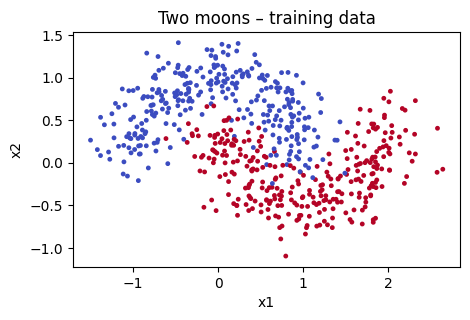

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3.4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=12, edgecolor="none")
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Two moons – training data"); plt.gca().set_aspect("equal")
plt.show()


## 2. Create PyTorch model exported as a Python bundle

The server unpacks `submission.zip` in an isolated container (no network, 1 CPU, 512 MB, 30 s) and calls

```python
def predict(X):   # X: numpy (N, 2)  ->  numpy (N,) probabilities of class 1
```

Everything your `predict` needs (architecture, weight loading) must live in `submission.py` and load files **relative to `__file__`**.
We write `submission.py` first so the notebook and the bundle share one model definition.


In [ ]:
%%writefile submission.py
import os
import numpy as np
import torch
import torch.nn as nn

HERE = os.path.dirname(os.path.abspath(__file__))


class MLP(nn.Module):
    # TO-DO: Create the model's __init__ and forward methods


_model = None


def _load():
    global _model
    if _model is None:
        m = MLP()
        m.load_state_dict(torch.load(os.path.join(HERE, "weights.pt"), map_location="cpu"))
        m.eval()
        _model = m
    return _model


def predict(X):
    """X: numpy.ndarray (N, 2) -> numpy.ndarray (N,) with P(class 1)."""
    model = _load()
    with torch.no_grad():
        logits = model(torch.as_tensor(np.asarray(X, dtype=np.float32)))
        return torch.sigmoid(logits).numpy().astype(np.float64)


In [ ]:
import importlib, torch, torch.nn.functional as F
import submission
importlib.reload(submission)

torch.manual_seed(0)
model = submission.MLP()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
Xt = torch.as_tensor(X_train); yt = torch.as_tensor(y_train, dtype=torch.float32)
for epoch in range(400):
    # TO-DO: Create the training loop (check previous exercises)
torch.save(model.state_dict(), "weights.pt")
print("saved weights.pt")


In [ ]:
# Sanity-check the bundle exactly as the server will use it, then zip it.
import zipfile
importlib.reload(submission)
p = submission.predict(X_test[:5])
print("predict() ->", p.shape, p.round(3))
assert p.shape == (5,) and np.all((p >= 0) & (p <= 1))

with zipfile.ZipFile("submission.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write("submission.py")
    zf.write("weights.pt")
print("submission.zip:", [i.filename for i in zipfile.ZipFile("submission.zip").infolist()])

try:
    from google.colab import files  # type: ignore
    files.download("submission.zip")
except ImportError:
    print("Not in Colab: submission.zip is in the current directory.")
